In [15]:
using Pkg
Pkg.activate("./../../")
Pkg.instantiate()
using DataFrames
using CSV

using Revise
includet("dementia_data_functions.jl")

  Activating environment at `~/Desktop/mini_transformer/Project.toml`


In [16]:
# Load the data

df = CSV.read("../../../dementia_data/forStratos_T0T30_3772subjects.csv", DataFrame)

Row,Column1,id,male,educ,age0,prevdem,dem1_30,agedem,death,agedeath,Tvisit,visit,time,dem,mms,cou_15,ani_15,fru_15,vil_15,isa_15,benton,cod_w,csd,csd_14,livalone,hier,medication
,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Float64,Int64,String31,Int64,Int64,Float64,Int64,String3,String3,String3,String3,String3,String3,String3,String3,String3,String3,String3,String3,String3
1,16983,1,0,0,89.8333,0,0,93.0941,1,93.368925393566,0,1,0.0,0,23,6,4,6,4,20,7,NA,26,3,NA,3,7
2,16986,1,0,0,89.8333,0,0,93.0941,1,93.368925393566,1,2,1.0514,0,27,NA,NA,NA,NA,NA,NA,NA,26,0,0,3,3
3,16987,1,0,0,89.8333,0,0,93.0941,1,93.368925393566,3,3,3.2608,0,22,5,3,3,5,16,NA,NA,26,0,0,3,2
4,14753,2,1,0,68.75,0,0,78.7404,1,78.8336755646817,0,1,0.0,0,22,6,6,6,5,23,11,18,8,0,NA,1,8
5,14752,2,1,0,68.75,0,0,78.7404,1,78.8336755646817,1,2,1.191,0,27,6,6,6,7,25,10,18,0,0,1,1,5
6,14757,2,1,0,68.75,0,0,78.7404,1,78.8336755646817,3,3,3.1896,0,26,7,7,5,7,26,12,NA,6,0,1,1,5
7,14754,2,1,0,68.75,0,0,78.7404,1,78.8336755646817,5,4,5.2348,0,23,9,5,4,5,23,10,18,12,3,1,1,9
8,14756,2,1,0,68.75,0,0,78.7404,1,78.8336755646817,8,5,7.6085,0,25,6,5,5,7,23,10,16,11,1,1,1,5
9,14755,2,1,0,68.75,0,0,78.7404,1,78.8336755646817,10,6,9.99042,0,25,6,5,7,4,22,12,14,18,1,1,2,8


## convert string to float

In [17]:
for c in names(df)
    col_type = eltype(df[!, c])

    if col_type <: AbstractString || col_type == Any
        
        # Replace "NA" with -Inf
        df[!, c] = replace(df[!, c], "NA" => -Inf)
        
        # Convert to Float64, handling both strings and numbers
        df[!, c] = [
            if ismissing(x)
                missing
            elseif isa(x, Number)
                convert(Float64, x)
            elseif isa(x, AbstractString)
                tryparse(Float64, x) === nothing ? missing : parse(Float64, x)
            else
                missing
            end
            for x in df[!, c]
        ]
        
    end
end


## dem variable: longitudinal indicator of dementia

In [18]:

# Assuming the columns are "id" for individual identifier, "dem" for dementia indicator,
# and "visit" or "time_point" to indicate the chronological order of visits
# We'll group the data by the "id" column, sort by the visit number, and check for any reversals in the "dem" column
reversing_ids = []
last_visit_dementia_ids = []
consistent_diagnosis_ids = []

# Group by each individual and check for reversion of dementia status
for group in groupby(df, :id)
    # Sort the group by the visit number or time point
    sorted_group = sort(group, :visit)  # Replace :visit with the actual column name for time or visit
    
    # Get the dementia status for the current group (individual)
    dem_status = sorted_group[!, :dem]
    
    # Check if there's any reversion (1 followed by 0)
    for i in 1:(length(dem_status) - 1)
        if dem_status[i] == 1 && dem_status[i + 1] == 0
            push!(reversing_ids, group[1, :id])  # Add the individual's id to the list
            break  # No need to check further for this individual
        end
    end


     # Check for first occurrence of dem = 1 and if all subsequent values are also 1
    first_diagnosis_index = findfirst(x -> x == 1, dem_status)  # Find the first index where dem == 1

    # If there is a first dementia diagnosis
    if first_diagnosis_index !== nothing
        # Check if all subsequent values after the first dementia diagnosis are 1
        if all(x -> x == 1, dem_status[first_diagnosis_index:end])
            push!(consistent_diagnosis_ids, group[1, :id])  # Add the individual's id to the list
        end
    end

    # Check if the last visit for the individual has dementia (dem = 1)
    if dem_status[end] == 1
        push!(last_visit_dementia_ids, group[1, :id])  # Add the individual's id to the list
    end
end

# Output the number of individuals with reverting dementia status
println("Number of individuals with reverting dementia status: ", length(Set(reversing_ids)))
# println("List of individuals with reverting dementia status: ", reversing_ids)

# Output the number of individuals with dementia diagnosis at the last visit
println("Number of individuals with dementia diagnosis at the last visit: ", length(Set(last_visit_dementia_ids)))  ## for one id only last visit is 1 but 2 visits before it is one again. id = 2283
# println("List of individuals with dementia diagnosis at the last visit: ", last_visit_dementia_ids)

# Output the number of individuals who are consistently diagnosed with dementia after first diagnosis
println("Number of individuals consistently diagnosed with dementia after first diagnosis: ", length(Set(consistent_diagnosis_ids)))
# println("List of individuals consistently diagnosed with dementia after first diagnosis: ", consistent_diagnosis_ids)


# Output the number of individuals who are not diagnosed by dementia
println("Number of individuals who are not diagnosed by dementia during the study: ", length(Set(df.id[df.dem1_30 .== 0])))
# println("List of individuals who are not diagnosed by dementia during the study: ", collect(Set(df.id[df.dem1_30 .== 0])))

# Output the number of individuals who are diagnosed by dementia at baseline 
println("Number of individuals who are diagnosed by dementia at baseline: ", length(Set(df.id[df.prevdem .== 1])))
# println("List of individuals who are diagnosed by dementia at baseline: ", collect(Set(df.id[df.prevdem .== 1])))

Number of individuals with reverting dementia status: 529
Number of individuals with dementia diagnosis at the last visit: 515
Number of individuals consistently diagnosed with dementia after first diagnosis: 514
Number of individuals who are not diagnosed by dementia during the study: 2831
Number of individuals who are diagnosed by dementia at baseline: 102


In [19]:
setdiff(last_visit_dementia_ids, intersect(consistent_diagnosis_ids, last_visit_dementia_ids))

1-element Vector{Any}:
 2283

#### 529 has baseline diagnosis in it & 2831 has baseline diagnosis in it

In [20]:
(2831-102) + 529 -102 + 514 + 102

3772

### correct dem variable

In [21]:
df = correct_dem_variable!(df)

Row,Column1,id,male,educ,age0,prevdem,dem1_30,agedem,death,agedeath,Tvisit,visit,time,dem,mms,cou_15,ani_15,fru_15,vil_15,isa_15,benton,cod_w,csd,csd_14,livalone,hier,medication
,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Float64,Int64,Float64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,16983,1,0,0,89.8333,0,0,93.0941,1,93.3689,0,1,0.0,0,23.0,6.0,4.0,6.0,4.0,20.0,7.0,-Inf,26.0,3.0,-Inf,3.0,7.0
2,16986,1,0,0,89.8333,0,0,93.0941,1,93.3689,1,2,1.0514,0,27.0,-Inf,-Inf,-Inf,-Inf,-Inf,-Inf,-Inf,26.0,0.0,0.0,3.0,3.0
3,16987,1,0,0,89.8333,0,0,93.0941,1,93.3689,3,3,3.2608,0,22.0,5.0,3.0,3.0,5.0,16.0,-Inf,-Inf,26.0,0.0,0.0,3.0,2.0
4,14753,2,1,0,68.75,0,0,78.7404,1,78.8337,0,1,0.0,0,22.0,6.0,6.0,6.0,5.0,23.0,11.0,18.0,8.0,0.0,-Inf,1.0,8.0
5,14752,2,1,0,68.75,0,0,78.7404,1,78.8337,1,2,1.191,0,27.0,6.0,6.0,6.0,7.0,25.0,10.0,18.0,0.0,0.0,1.0,1.0,5.0
6,14757,2,1,0,68.75,0,0,78.7404,1,78.8337,3,3,3.1896,0,26.0,7.0,7.0,5.0,7.0,26.0,12.0,-Inf,6.0,0.0,1.0,1.0,5.0
7,14754,2,1,0,68.75,0,0,78.7404,1,78.8337,5,4,5.2348,0,23.0,9.0,5.0,4.0,5.0,23.0,10.0,18.0,12.0,3.0,1.0,1.0,9.0
8,14756,2,1,0,68.75,0,0,78.7404,1,78.8337,8,5,7.6085,0,25.0,6.0,5.0,5.0,7.0,23.0,10.0,16.0,11.0,1.0,1.0,1.0,5.0
9,14755,2,1,0,68.75,0,0,78.7404,1,78.8337,10,6,9.99042,0,25.0,6.0,5.0,7.0,4.0,22.0,12.0,14.0,18.0,1.0,1.0,2.0,8.0


## individials and number of time points

In [29]:
using Plots

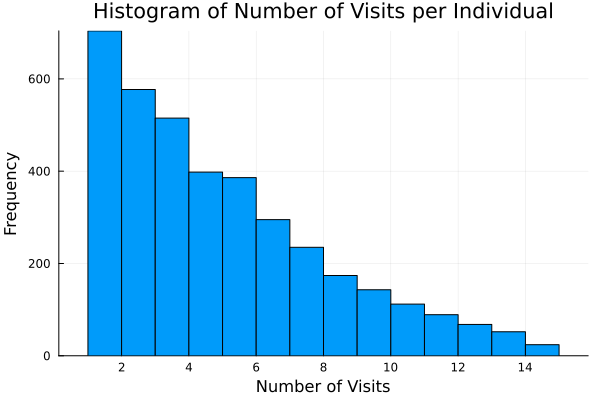

In [30]:
# Assuming the columns are "id" for individual identifier and "visit" for the visit number
# Count the number of visits for each individual
visit_counts = combine(groupby(df, :id), nrow => :number_of_visits)

# Display the number of visits for each individual
# println("Number of visits for each individual:")
# println(visit_counts)

# Now, calculate the frequency of individuals with different numbers of visits
visit_frequency = combine(groupby(visit_counts, :number_of_visits), nrow => :frequency)

# Display the frequency of number of visits
# println("Frequency of number of visits:")
# println(visit_frequency)


# Plot a histogram of the number of visits
histogram(visit_counts.number_of_visits, 
          bins = 15, 
          title = "Histogram of Number of Visits per Individual", 
          xlabel = "Number of Visits", 
          ylabel = "Frequency",
          legend = false)

### how many individuals have at least two visits?


In [38]:
count(visit_counts.number_of_visits .>1)

3068

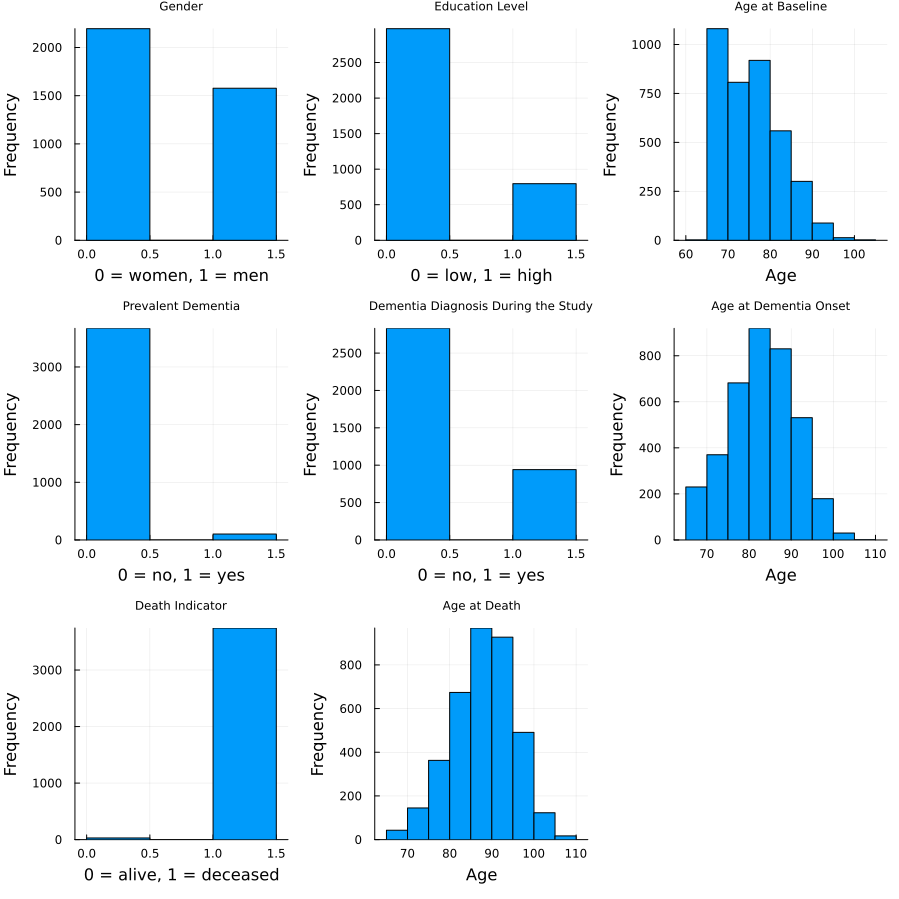

In [31]:
# get baseline df for time fixed variables
baseline_df = df[df.Tvisit .== 0, :]

# Set up a layout for subplots
nrows = 3  # Number of rows in the subplot grid
ncols = 3  # Number of columns in the subplot grid
layout = @layout [a b c; d e f; g h i]  # Adjust this if needed depending on number of variables

# Create the subplots for each variable and place them in the grid
p1 = histogram(baseline_df.male, bins = 2, title = "Gender", xlabel = "0 = women, 1 = men", ylabel = "Frequency", legend = false)
p2 = histogram(baseline_df.educ, bins = 2, title = "Education Level", xlabel = "0 = low, 1 = high", ylabel = "Frequency", legend = false)
p3 = histogram(baseline_df.age0, bins = 10, title = "Age at Baseline", xlabel = "Age", ylabel = "Frequency", legend = false)
p4 = histogram(baseline_df.prevdem, bins = 2, title = "Prevalent Dementia", xlabel = "0 = no, 1 = yes", ylabel = "Frequency", legend = false)
p5 = histogram(baseline_df.dem1_30, bins = 2, title = "Dementia Diagnosis During the Study", xlabel = "0 = no, 1 = yes", ylabel = "Frequency", legend = false)

# Optional histograms for age at dementia onset and age at death, only if columns are available
p6 = histogram(baseline_df.agedem, bins = 10, title = "Age at Dementia Onset", xlabel = "Age", ylabel = "Frequency", legend = false)
p7 = histogram(baseline_df.death, bins = 2, title = "Death Indicator", xlabel = "0 = alive, 1 = deceased", ylabel = "Frequency", legend = false)
p8 = histogram(baseline_df.agedeath, bins = 10, title = "Age at Death", xlabel = "Age", ylabel = "Frequency", legend = false)


# Plot all histograms together in a single layout
combined_plot = plot(p1, p2, p3, p4, p5, p6, p7, p8, layout = layout, size = (900, 900), titlefont = (8,))

# Add the global title for the entire plot
plot!(combined_plot)

## make a dataframe using the normal thresholds

In [32]:
# change the data to have zero values for normal tests and 1 for impairment indication
df_classified = impairment_classification(df)


# change the data to have two variables for medication both zero if no change in medication and 1 for one of them if there is an increase and 1 for the other if there is a decrease
df_classified_with_medications = medication_report(df_classified)

Row,Column1,id,male,educ,age0,prevdem,dem1_30,agedem,death,agedeath,Tvisit,visit,time,dem,mms,cou_15,ani_15,fru_15,vil_15,isa_15,benton,cod_w,csd,csd_14,livalone,hier,medication_increase,medication_decrease
,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Float64,Int64,Float64,Int64,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Int64
1,16983,1,0,0,89.8333,0,0,93.0941,1,93.3689,0,1,0.0,0,1,1,1,1,1,1,0,1,1,1,-Inf,1,0,0
2,16986,1,0,0,89.8333,0,0,93.0941,1,93.3689,1,2,1.0514,0,0,1,1,1,1,1,1,1,1,0,0.0,1,0,1
3,16987,1,0,0,89.8333,0,0,93.0941,1,93.3689,3,3,3.2608,0,1,1,1,1,1,1,1,1,1,0,0.0,1,0,1
4,14753,2,1,0,68.75,0,0,78.7404,1,78.8337,0,1,0.0,0,1,1,1,1,1,1,0,1,0,0,-Inf,0,0,0
5,14752,2,1,0,68.75,0,0,78.7404,1,78.8337,1,2,1.191,0,0,1,1,1,0,1,0,1,0,0,1.0,0,0,1
6,14757,2,1,0,68.75,0,0,78.7404,1,78.8337,3,3,3.1896,0,0,1,1,1,0,1,0,1,0,0,1.0,0,0,0
7,14754,2,1,0,68.75,0,0,78.7404,1,78.8337,5,4,5.2348,0,1,0,1,1,1,1,0,1,0,1,1.0,0,1,0
8,14756,2,1,0,68.75,0,0,78.7404,1,78.8337,8,5,7.6085,0,0,1,1,1,0,1,0,1,0,0,1.0,0,0,1
9,14755,2,1,0,68.75,0,0,78.7404,1,78.8337,10,6,9.99042,0,0,1,1,1,1,1,0,1,1,0,1.0,1,1,0


In [33]:
# save the df to a csv file
CSV.write("../../../dementia_data/forStratos_T0T30_3772subjects_classified.csv", df_classified_with_medications)

"../../../dementia_data/forStratos_T0T30_3772subjects_classified.csv"

In [34]:
frequency_id_dict, sample_size,  median, average = get_dictionary_plot_id_datapoint(df_classified_with_medications)


println("average length (number of time points): ", average)
println("median length (number of time points): ", median)
println("sample size (number of time points): ", sample_size)


average length (number of time points): 4.492576882290562
median length (number of time points): 4.0
sample size (number of time points): 3772


In [36]:
current_data_path, df, word_to_vec_dict, vector_sequence_dict, data_sentence_string_set_new = prepare_sequences_for_dementia_data()

("/Users/farhadyar/Desktop/mini_transformer/data/dementia_data//data_version/data_1", 16946×18 DataFrame
   Row │ id     visit  time      dem    mms    cou_15  ani_15  fru_15  vil_15  ⋯
       │ Int64  Int64  Float64   Int64  Int64  Int64   Int64   Int64   Int64   ⋯
───────┼────────────────────────────────────────────────────────────────────────
     1 │     1      1   0.0          0      1       1       1       1       1  ⋯
     2 │     1      2   1.0514       0      0       1       1       1       1
     3 │     1      3   3.2608       0      1       1       1       1       1
     4 │     2      1   0.0          0      1       1       1       1       1
     5 │     2      2   1.191        0      0       1       1       1       0  ⋯
     6 │     2      3   3.1896       0      0       1       1       1       0
     7 │     2      4   5.2348       0      1       0       1       1       1
     8 │     2      5   7.6085       0      0       1       1       1       0
   ⋮   │   ⋮      ⋮   